# 🔬 Autoencoder + LSTM for Predictive Maintenance

## Konsep (v2 - Minimal Features)
```
Priority & Impact (2 features)
           ↓
┌──────────────────────┐
│    AUTOENCODER       │  ← Train on NORMAL data only
│     2 → 4 → 2        │
└──────────────────────┘
           ↓
    Reconstruction Error  (anomaly score)
           ↓
┌──────────────────────┐
│  Priority + Impact   │
│  + recon_error       │  = 3 features
└──────────────────────┘
           ↓
┌──────────────────────┐
│   ATTENTION LSTM     │
└──────────────────────┘
           ↓
       Prediction
```

## Key Points
- AE di-train dengan **Priority & Impact** (2 fitur dasar)
- AE di-train dengan data **NORMAL only** (label=0)
- Output = **reconstruction error** sebagai anomaly score
- Final = **Priority + Impact + recon_error = 3 features**
- LSTM hanya melihat 3 fitur ini

In [61]:
# === 0. Install PyTorch if needed ===
# !pip install torch

In [62]:
# === 1. Import Libraries ===
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, confusion_matrix
)
from imblearn.over_sampling import SMOTE

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")

# Import LSTM models
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  
from src.model.lstm_attention_optimized import AttentionLSTMModelGPUOptimized
from src.model.lstm_nested_attention import NestedAttentionLSTMModelGPUOptimized
from src.utils.model_io import save_model

print(f"✅ Libraries loaded")

🖥️ Device: cuda
✅ Libraries loaded


In [63]:
# === 2. Load and Preprocess Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)

print(f"✅ Data loaded: {df.shape}")

✅ Data loaded: (18969, 13)


In [64]:
# === 3. Create f19-ultimate Features ===
print("🔧 Creating features...")

# Temporal
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek

# Interactions
df['priority_impact_product'] = df['Priority'] * df['Impact']
df['priority_impact_sum'] = df['Priority'] + df['Impact']
df['risk_score'] = (0.6 * df['Priority']) + (0.4 * df['Impact'])
df['priority_squared'] = df['Priority'] ** 2
df['impact_squared'] = df['Impact'] ** 2
df['priority_hour_interaction'] = df['Priority'] * df['hour']
df['impact_hour_interaction'] = df['Impact'] * df['hour']
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Service
service_rates = df.groupby('Service Type')['incident'].mean()
df['service_risk_score'] = df['Service Type'].map(service_rates).fillna(service_rates.mean())
service_freq = df['Service Type'].value_counts(normalize=True)
df['service_frequency'] = df['Service Type'].map(service_freq).fillna(0)

# Sequence
df['priority_volatility'] = df['Priority'].rolling(4, min_periods=1).std().fillna(0).clip(0, 5)
df['impact_volatility'] = df['Impact'].rolling(4, min_periods=1).std().fillna(0).clip(0, 5)
df['priority_change'] = df['Priority'].diff().fillna(0)
df['incidents_last_2h'] = df['incident'].rolling(4, min_periods=1).sum()
df['consecutive_high_priority'] = (df['Priority'] >= 2).rolling(6, min_periods=1).sum()
df['priority_acceleration'] = df['Priority'].diff().diff().fillna(0)

# Feature list (19 features)
FEATURE_COLS = [
    'Priority', 'Impact',
    'priority_impact_product', 'priority_impact_sum', 'risk_score',
    'priority_squared', 'impact_squared',
    'priority_hour_interaction', 'impact_hour_interaction',
    'hour_sin', 'hour_cos',
    'service_risk_score', 'service_frequency',
    'priority_volatility', 'impact_volatility',
    'incidents_last_2h', 'consecutive_high_priority',
    'priority_change', 'priority_acceleration'
]

print(f"✅ {len(FEATURE_COLS)} features created")

🔧 Creating features...
✅ 19 features created


In [65]:
# === 4. Resample Data ===
SAMPLING_PERIOD = '30min'
WINDOW_SIZE = 48
ROLLING_MEANS = []

# Aggregation
agg_dict = {'incident': 'sum'}
for f in FEATURE_COLS:
    agg_dict[f] = 'first' if f in ['hour', 'day_of_week'] else 'mean'

df_rs = (df.set_index('Timestamp')
           .resample(SAMPLING_PERIOD)
           .agg(agg_dict)
           .fillna(0)
           .reset_index())
df_rs['incident'] = (df_rs['incident'] > 0).astype(int)

# Rolling means
feature_cols = FEATURE_COLS.copy()
for rm in ROLLING_MEANS:
    df_rs[f'Priority_rm{rm}h'] = df_rs['Priority'].rolling(rm*2, min_periods=1).mean()
    df_rs[f'Impact_rm{rm}h'] = df_rs['Impact'].rolling(rm*2, min_periods=1).mean()
    feature_cols += [f'Priority_rm{rm}h', f'Impact_rm{rm}h']

print(f"✅ Resampled: {df_rs.shape}")
print(f"   Features: {len(feature_cols)}")

✅ Resampled: (14640, 21)
   Features: 19


In [66]:
# === 5. Create Windows (Memory Efficient) ===
import gc

def create_windows(df, features, target, win_size):
    """Memory-efficient windowing using numpy."""
    data = df[features].values.astype(np.float32)
    labels = df[target].values
    
    n_samples = len(df) - win_size
    n_features = len(features)
    
    X = np.zeros((n_samples, win_size, n_features), dtype=np.float32)
    y = np.zeros(n_samples, dtype=np.int32)
    
    for i in range(n_samples):
        X[i] = data[i:i+win_size]
        y[i] = labels[i+win_size]
    
    return X, y

gc.collect()
X_all, y_all = create_windows(df_rs, feature_cols, 'incident', WINDOW_SIZE)
n_features = X_all.shape[2]

print(f"✅ X: {X_all.shape}, y: {y_all.shape}")
print(f"   Class dist: {np.bincount(y_all)}")
print(f"   Memory: {X_all.nbytes / 1e6:.1f} MB")

✅ X: (14592, 48, 19), y: (14592,)
   Class dist: [10112  4480]
   Memory: 53.2 MB


In [67]:
# === 6. Train/Val/Test Split ===
X_temp, X_test, y_temp, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Normal data only for AE
X_train_normal = X_train[y_train == 0]
X_val_normal = X_val[y_val == 0]

print(f"✅ Split:")
print(f"   Train: {len(X_train)} (normal: {len(X_train_normal)})")
print(f"   Val: {len(X_val)} (normal: {len(X_val_normal)})")
print(f"   Test: {len(X_test)}")

✅ Split:
   Train: 8754 (normal: 6066)
   Val: 2919 (normal: 2023)
   Test: 2919


---
## 🧠 Autoencoder (PyTorch)

In [68]:
# === 7. Define Simple Autoencoder for Priority & Impact ===

class SimpleAutoencoder(nn.Module):
    """
    Simple Dense Autoencoder for Priority & Impact only.
    Input: (batch, seq_len, 2)  - just Priority and Impact
    Output: (batch, seq_len, 2) - reconstructed
    """
    def __init__(self, seq_len=48, n_features=2, latent_size=4):
        super().__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        input_size = seq_len * n_features  # Flatten: 48 * 2 = 96
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_size),
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_size),
        )
        
    def forward(self, x):
        # x: (batch, seq, 2)
        batch_size = x.shape[0]
        x_flat = x.reshape(batch_size, -1)  # (batch, seq*2)
        
        latent = self.encoder(x_flat)
        recon = self.decoder(latent)
        
        return recon.reshape(batch_size, self.seq_len, self.n_features)
    
    def get_reconstruction_error(self, x):
        """Per-sample MSE reconstruction error."""
        with torch.no_grad():
            recon = self.forward(x)
            error = torch.mean((x - recon) ** 2, dim=(1, 2))  # (batch,)
        return error

# Base features for AE
BASE_FEATURES = ['Priority', 'Impact']
print(f"✅ SimpleAutoencoder defined")
print(f"   AE input: {BASE_FEATURES} (2 features)")

✅ SimpleAutoencoder defined
   AE input: ['Priority', 'Impact'] (2 features)


In [69]:
# === 8. Train Autoencoder on Priority & Impact ===

# Config
AE_CONFIG = {
    'latent_size': 4,
    'epochs': 100,
    'batch_size': 64,
    'lr': 0.001,
    'patience': 15,
}

print("="*60)
print("🧠 TRAINING AUTOENCODER (Priority & Impact only)")
print("="*60)
print(f"Config: {AE_CONFIG}\n")

# Extract Priority & Impact only (indices 0 and 1 in feature_cols)
priority_idx = feature_cols.index('Priority')
impact_idx = feature_cols.index('Impact')

X_train_base = X_train[:, :, [priority_idx, impact_idx]]  # (samples, 48, 2)
X_val_base = X_val[:, :, [priority_idx, impact_idx]]
X_test_base = X_test[:, :, [priority_idx, impact_idx]]

# Normal data only for AE training
X_train_base_normal = X_train_base[y_train == 0]
X_val_base_normal = X_val_base[y_val == 0]

print(f"📊 AE Training data (NORMAL only):")
print(f"   Train: {X_train_base_normal.shape}")
print(f"   Val: {X_val_base_normal.shape}")

# Normalize (fit on normal data only)
scaler_base = StandardScaler()
X_train_base_normal_flat = X_train_base_normal.reshape(-1, 2)
scaler_base.fit(X_train_base_normal_flat)

def normalize_base(X, scaler):
    shape = X.shape
    X_flat = X.reshape(-1, 2)
    X_norm = scaler.transform(X_flat)
    return X_norm.reshape(shape).astype(np.float32)

X_train_norm = normalize_base(X_train_base_normal, scaler_base)
X_val_norm = normalize_base(X_val_base_normal, scaler_base)

# DataLoaders
train_ds = TensorDataset(torch.from_numpy(X_train_norm))
val_ds = TensorDataset(torch.from_numpy(X_val_norm))
train_loader = DataLoader(train_ds, batch_size=AE_CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=AE_CONFIG['batch_size'])

# Model
autoencoder = SimpleAutoencoder(
    seq_len=WINDOW_SIZE,
    n_features=2,
    latent_size=AE_CONFIG['latent_size']
).to(device)

optimizer = optim.Adam(autoencoder.parameters(), lr=AE_CONFIG['lr'])
criterion = nn.MSELoss()

# Training loop
best_val_loss = float('inf')
patience_counter = 0
history = {'train': [], 'val': []}

print(f"\nTraining...")
for epoch in range(AE_CONFIG['epochs']):
    # Train
    autoencoder.train()
    train_loss = 0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon = autoencoder(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    history['train'].append(train_loss)
    
    # Validate
    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)
            recon = autoencoder(batch)
            val_loss += criterion(recon, batch).item()
    val_loss /= len(val_loader)
    history['val'].append(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = autoencoder.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= AE_CONFIG['patience']:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

# Load best
autoencoder.load_state_dict(best_state)
print(f"\n✅ AE trained. Best val loss: {best_val_loss:.6f}")

🧠 TRAINING AUTOENCODER (Priority & Impact only)
Config: {'latent_size': 4, 'epochs': 100, 'batch_size': 64, 'lr': 0.001, 'patience': 15}

📊 AE Training data (NORMAL only):
   Train: (6066, 48, 2)
   Val: (2023, 48, 2)

Training...
Epoch  10 | Train: 0.654819 | Val: 0.663062
Epoch  20 | Train: 0.644885 | Val: 0.656352
Epoch  30 | Train: 0.640284 | Val: 0.653045
Epoch  40 | Train: 0.637306 | Val: 0.652117
Epoch  50 | Train: 0.635408 | Val: 0.651138
Epoch  60 | Train: 0.633635 | Val: 0.650449
Epoch  70 | Train: 0.632424 | Val: 0.649585
Epoch  80 | Train: 0.630860 | Val: 0.649612
Epoch  90 | Train: 0.629999 | Val: 0.648914
Epoch 100 | Train: 0.628830 | Val: 0.648231

✅ AE trained. Best val loss: 0.647875


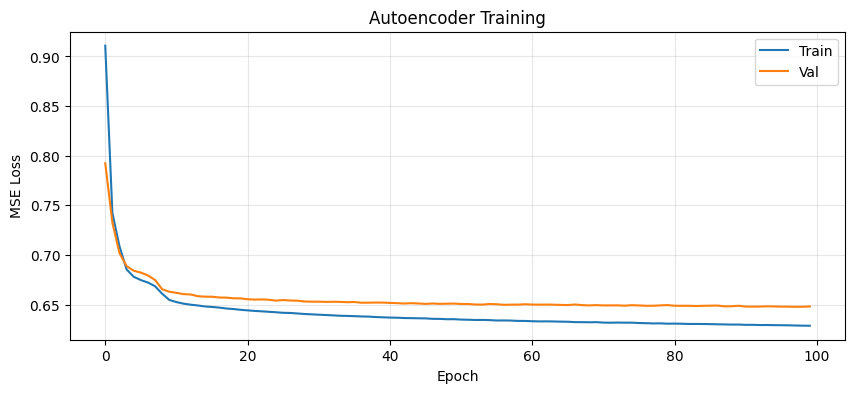

In [70]:
# === 9. Plot Training ===
plt.figure(figsize=(10, 4))
plt.plot(history['train'], label='Train')
plt.plot(history['val'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [71]:
# === 10. Compute Reconstruction Error (Anomaly Score) ===

print("📊 Computing reconstruction error as anomaly score...")

def compute_recon_error(X_base, scaler, autoencoder, device):
    """
    Compute reconstruction error for Priority & Impact.
    X_base: (samples, seq, 2) - Priority and Impact only
    Returns: (samples,) - reconstruction error per sample
    """
    X_norm = normalize_base(X_base, scaler)
    X_tensor = torch.from_numpy(X_norm).to(device)
    
    autoencoder.eval()
    with torch.no_grad():
        recon_error = autoencoder.get_reconstruction_error(X_tensor)
    
    return recon_error.cpu().numpy()

# Compute error for all sets (using base features)
train_error = compute_recon_error(X_train_base, scaler_base, autoencoder, device)
val_error = compute_recon_error(X_val_base, scaler_base, autoencoder, device)
test_error = compute_recon_error(X_test_base, scaler_base, autoencoder, device)

print(f"✅ Reconstruction errors computed")
print(f"   Train: mean={train_error.mean():.4f}, std={train_error.std():.4f}")
print(f"   Val:   mean={val_error.mean():.4f}, std={val_error.std():.4f}")
print(f"   Test:  mean={test_error.mean():.4f}, std={test_error.std():.4f}")

📊 Computing reconstruction error as anomaly score...
✅ Reconstruction errors computed
   Train: mean=0.6362, std=0.2096
   Val:   mean=0.6493, std=0.2150
   Test:  mean=0.6457, std=0.2178


C:\Users\Mahesa\AppData\Local\Temp\ipykernel_28588\2241922283.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([test_error[y_test==0], test_error[y_test==1]],


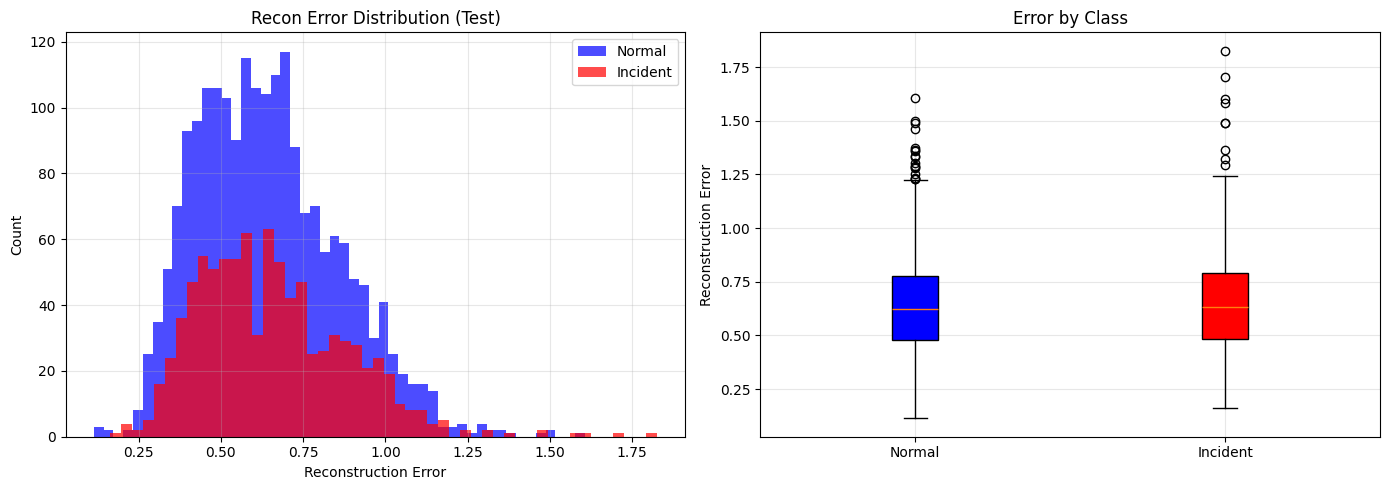


📊 Class Separation: 0.06 std deviations
   Normal mean:   0.6418
   Incident mean: 0.6545


In [72]:
# === 11. Visualize Reconstruction Error by Class ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(test_error[y_test == 0], bins=50, alpha=0.7, label='Normal', color='blue')
ax.hist(test_error[y_test == 1], bins=50, alpha=0.7, label='Incident', color='red')
ax.set_xlabel('Reconstruction Error')
ax.set_ylabel('Count')
ax.set_title('Recon Error Distribution (Test)')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot
ax = axes[1]
bp = ax.boxplot([test_error[y_test==0], test_error[y_test==1]], 
                labels=['Normal', 'Incident'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('red')
ax.set_ylabel('Reconstruction Error')
ax.set_title('Error by Class')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stats
sep = (test_error[y_test==1].mean() - test_error[y_test==0].mean()) / test_error[y_test==0].std()
print(f"\n📊 Class Separation: {sep:.2f} std deviations")
print(f"   Normal mean:   {test_error[y_test==0].mean():.4f}")
print(f"   Incident mean: {test_error[y_test==1].mean():.4f}")

In [73]:
# === 12. Create Final Features: Priority + Impact + recon_error ===

print("🔧 Creating final features (Priority + Impact + recon_error)...")

def create_final_features(X_base, recon_error):
    """
    Create final features: Priority + Impact + recon_error
    X_base: (samples, seq, 2) - Priority and Impact
    recon_error: (samples,) - anomaly score from AE
    Returns: (samples, seq, 3) - P + I + error
    """
    n_samples, seq_len, _ = X_base.shape
    
    # Expand error to (samples, seq, 1) - same value for all timesteps
    error_expanded = np.repeat(recon_error[:, np.newaxis, np.newaxis], seq_len, axis=1)
    
    # Concatenate: Priority + Impact + recon_error
    X_final = np.concatenate([X_base, error_expanded], axis=2)
    return X_final.astype(np.float32)

# Use base features (Priority, Impact) + recon_error
X_train_final = create_final_features(X_train_base, train_error)
X_val_final = create_final_features(X_val_base, val_error)
X_test_final = create_final_features(X_test_base, test_error)

print(f"✅ Final features: {X_train_final.shape[2]}")
print(f"   [0] Priority")
print(f"   [1] Impact")
print(f"   [2] recon_error (anomaly score)")

🔧 Creating final features (Priority + Impact + recon_error)...
✅ Final features: 3
   [0] Priority
   [1] Impact
   [2] recon_error (anomaly score)


---
## 🏋️ Train LSTM Classifier

In [74]:
# === 13. SMOTE ===

print("📊 Applying SMOTE...")

X_train_flat = X_train_final.reshape(X_train_final.shape[0], -1)
X_smote_flat, y_smote = SMOTE(random_state=42).fit_resample(X_train_flat, y_train)
X_train_smote = X_smote_flat.reshape(-1, WINDOW_SIZE, X_train_final.shape[2])

print(f"✅ Before: {len(y_train)} | After: {len(y_smote)}")
print(f"   Class dist: {np.bincount(y_smote)}")

📊 Applying SMOTE...
✅ Before: 8754 | After: 12132
   Class dist: [6066 6066]


In [75]:
# === 14. Train LSTM ===

MODEL_TYPE = 'Attention'  # or 'Nested-Attention'

MODEL_REGISTRY = {
    'Attention': AttentionLSTMModelGPUOptimized,
    'Nested-Attention': NestedAttentionLSTMModelGPUOptimized,
}

print("="*60)
print(f"🧠 TRAINING {MODEL_TYPE} LSTM")
print("="*60)
print(f"Input: {X_train_final.shape[2]} features (Priority + Impact + recon_error)\n")

# Initialize
ModelClass = MODEL_REGISTRY[MODEL_TYPE]
model = ModelClass(input_size=X_train_final.shape[2], hidden_size=128, cw=1)

# Train
start = time.time()
model.train(
    X_train_smote, y_smote,
    X_val_final, y_val,
    epochs=100,
    batch_size=128,
    lr=0.001,
    print_every=10,
    patience=10
)
print(f"\n✅ Trained in {time.time()-start:.1f}s")

🧠 TRAINING Attention LSTM
Input: 3 features (Priority + Impact + recon_error)

Training: 12132 samples, 95 batches/epoch, batch_size=128
Validation: 2919 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch   10/100 | Train Loss: 0.6931 | Val Loss: 0.6934 | Val Acc: 0.3070 [UNDERFITTING]

🛑 Early stopping triggered at epoch 12
----------------------------------------------------------------------
Final - Train Loss: 0.6932 | Val Loss: 0.6930 | Val Acc: 0.3070

✅ Trained in 484.2s


In [76]:
# === 15. Evaluate ===

print("="*60)
print("📊 EVALUATION")
print("="*60)

# Predict
y_prob = model.predict(X_test_final, batch_size=128)
y_prob = np.array(y_prob).flatten()

# Optimal threshold
prec, rec, thresh = precision_recall_curve(y_test, y_prob)
f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
opt_idx = np.argmax(f1s)
opt_thresh = thresh[opt_idx] if opt_idx < len(thresh) else 0.5

y_pred = (y_prob >= opt_thresh).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"\n🎯 Results (threshold={opt_thresh:.3f}):")
print(f"   Accuracy:  {acc:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1 Score:  {f1:.4f}  ({f1*100:.2f}%)")
print(f"   ROC-AUC:   {roc_auc:.4f}  ({roc_auc*100:.2f}%)")

📊 EVALUATION

🎯 Results (threshold=0.486):
   Accuracy:  0.3203
   Precision: 0.3101
   Recall:    0.9911
   F1 Score:  0.4723  (47.23%)
   ROC-AUC:   0.5250  (52.50%)


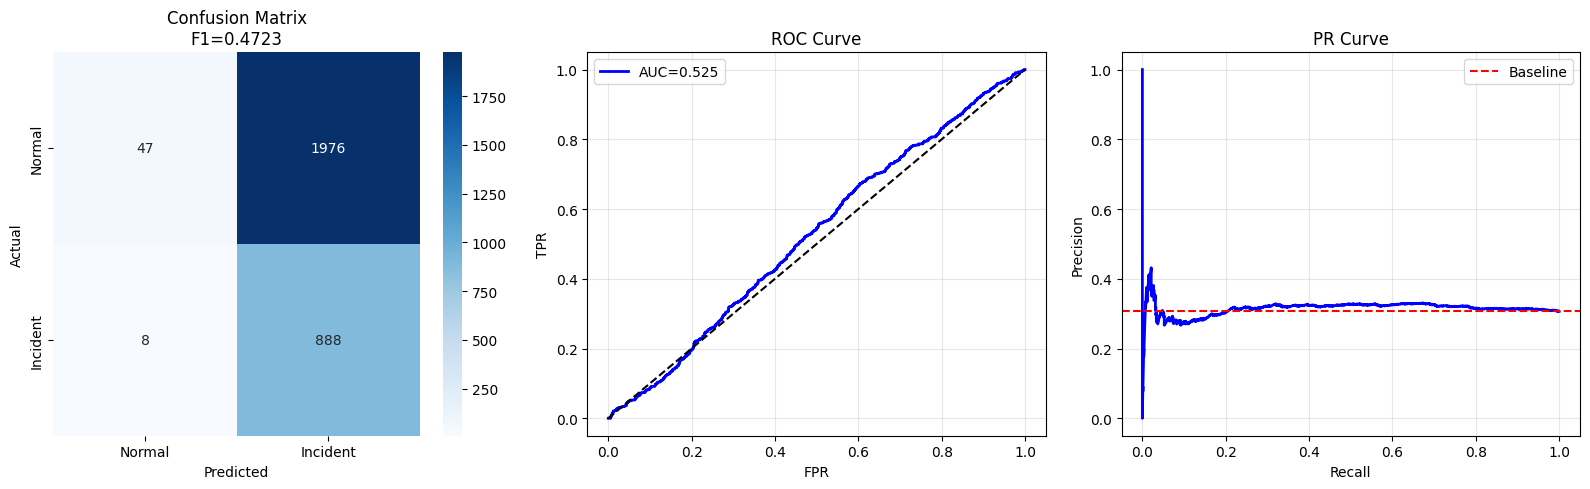

In [77]:
# === 16. Visualization ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Incident'], yticklabels=['Normal', 'Incident'])
axes[0].set_title(f'Confusion Matrix\nF1={f1:.4f}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# PR
axes[2].plot(rec, prec, 'b-', lw=2)
axes[2].axhline(y=sum(y_test)/len(y_test), color='r', ls='--', label='Baseline')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('PR Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/output/ae_lstm_results.png', dpi=150)
plt.show()

In [78]:
# === 17. Compare with Baseline ===

print("\n" + "="*60)
print("📊 COMPARISON")
print("="*60)

print(f"""
| Model                           | F1 Score | ROC-AUC | Features |
|---------------------------------|----------|---------|----------|
| Baseline (f19-Nested)           | 82.94%   | 90.94%  | 19       |
| AE(P+I)+{MODEL_TYPE:20s} | {f1*100:.2f}%   | {roc_auc*100:.2f}%  | 3        |

Δ F1:  {(f1-0.8294)*100:+.2f}%
Δ AUC: {(roc_auc-0.9094)*100:+.2f}%

Features used: Priority + Impact + recon_error (3 total)
""")


📊 COMPARISON

| Model                           | F1 Score | ROC-AUC | Features |
|---------------------------------|----------|---------|----------|
| Baseline (f19-Nested)           | 82.94%   | 90.94%  | 19       |
| AE(P+I)+Attention            | 47.23%   | 52.50%  | 3        |

Δ F1:  -35.71%
Δ AUC: -38.44%

Features used: Priority + Impact + recon_error (3 total)



In [79]:
# === 18. Save ===

output_dir = '../data/output_autoencoder'
os.makedirs(output_dir, exist_ok=True)

# Save LSTM
save_model(model, f'{output_dir}/ae_v2_lstm_{MODEL_TYPE.lower()}.pkl')

# Save AE
torch.save({
    'state_dict': autoencoder.state_dict(),
    'config': AE_CONFIG,
    'base_features': BASE_FEATURES,
    'seq_len': WINDOW_SIZE,
}, f'{output_dir}/autoencoder_v2.pt')

# Save scaler
import pickle
with open(f'{output_dir}/scaler_base_v2.pkl', 'wb') as f:
    pickle.dump(scaler_base, f)

# Save results
pd.DataFrame([{
    'model': f'AE_v2+{MODEL_TYPE}',
    'approach': 'Priority + Impact + recon_error',
    'f1': f1, 'roc_auc': roc_auc,
    'accuracy': acc, 'precision': precision, 'recall': recall,
    'threshold': opt_thresh,
    'ae_latent_size': AE_CONFIG['latent_size'],
    'ae_input_features': 'Priority, Impact',
    'lstm_input_features': 'Priority, Impact, recon_error',
    'n_features': 3,
}]).to_csv(f'{output_dir}/results_v2.csv', index=False)

print(f"💾 Saved to {output_dir}/")

✅ Model saved to ../data/output_autoencoder/ae_v2_lstm_attention.pkl
💾 Saved to ../data/output_autoencoder/
